# Clase 3: análisis del conjunto de datos US Health Care y un analisis de fairness




### Importación de librerías y paquetes

In [ ]:
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.3f}".format)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import Bunch

from sklearn import set_config

set_config(display="diagram")

from IPython import display
from datetime import date

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/fairlearn/talks/main/2021_scipy_tutorial/data/diabetic_preprocessed.csv")
df.head()

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,30 years or younger,Other,Referral,1,Other,41,0,1,...,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,30 years or younger,Discharged to Home,Emergency,3,Missing,59,0,18,...,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,30 years or younger,Discharged to Home,Emergency,2,Missing,11,5,13,...,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,30-60 years,Discharged to Home,Emergency,2,Missing,44,1,16,...,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,30-60 years,Discharged to Home,Emergency,1,Missing,51,0,8,...,Ch,Yes,False,False,False,False,False,NO,0,0


In [ ]:
# Veamos los posibles valores de las columnas categóricas y binarias
categorical_values = {}
for col in df:
  if col not in {'time_in_hospital', 'num_lab_procedures',
                 'num_procedures', 'num_medications', 'number_diagnoses'}:
    categorical_values[col] = pd.Series(df[col].value_counts().index.values)
categorical_values_df = pd.DataFrame(categorical_values).fillna('')
categorical_values_df.T

,0,1,2,3,4,5
race,Caucasian,AfricanAmerican,Unknown,Hispanic,Other,Asian
gender,Female,Male,Unknown/Invalid,,,
age,Over 60 years,30-60 years,30 years or younger,,,
discharge_disposition_id,Discharged to Home,Other,,,,
admission_source_id,Emergency,Referral,Other,,,
medical_specialty,Missing,Other,InternalMedicine,Emergency/Trauma,Family/GeneralPractice,Cardiology
primary_diagnosis,Other,Respiratory Issues,Diabetes,Genitourinary Issues,Musculoskeletal Issues,
max_glu_serum,Norm,>200,>300,,,
A1Cresult,>8,Norm,>7,,,
insulin,No,Steady,Down,Up,,


### Modificamos los tipos de las columnas categóricas

In [ ]:
categorical_features = [
    "race",
    "gender",
    "age",
    "discharge_disposition_id",
    "admission_source_id",
    "medical_specialty",
    "primary_diagnosis",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed",
    "readmitted"
]

for col_name in categorical_features:
  df[col_name] = df[col_name].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   race                      101766 non-null  category
 1   gender                    101766 non-null  category
 2   age                       101766 non-null  category
 3   discharge_disposition_id  101766 non-null  category
 4   admission_source_id       101766 non-null  category
 5   time_in_hospital          101766 non-null  int64   
 6   medical_specialty         101766 non-null  category
 7   num_lab_procedures        101766 non-null  int64   
 8   num_procedures            101766 non-null  int64   
 9   num_medications           101766 non-null  int64   
 10  primary_diagnosis         101766 non-null  category
 11  number_diagnoses          101766 non-null  int64   
 12  max_glu_serum             5346 non-null    category
 13  A1Cresult                 170

In [ ]:
# drop gender group Unknown/Invalid
df = df.query("gender != 'Unknown/Invalid'")

# retain the original race as race_all, and merge Asian+Hispanic+Other
df["race_all"] = df["race"]
df["race"] = df["race"].replace({"Asian": "Other", "Hispanic": "Other"})
#df["race"] =  df["race"].cat.rename_categories({"Asian": "Other", "Hispanic": "Other"})

/tmp/ipykernel_21031/4061970827.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["race"] = df["race"].replace({"Asian": "Other", "Hispanic": "Other"})


In [ ]:
df.to_csv('diabetic_preprocessed_clase3.csv')

# Clase 4: (continuación) análisis del conjunto de datos US Health Care y un analisis de fairness

## Entrenamiento del modelo inicial
Entrenamos un modelo de clasificación para predecir nuestra variable objetivo (readmisión dentro de los 30 días).

¿Qué tipo de modelo deberíamos entrenar? ¿ANN? ¿Random Forest? ¿Regresión logística?

Hay una variedad de consideraciones a realizar para esta selección. Destacamos dos:

* **Interpretabilidad**. La interpretabilidad está estrechamente vinculada con cuestiones de fairness. Hay varias razones por las que es importante contar con modelos interpretables que estén abiertos al escrutinio de las partes interesadas:
  * Permite descubrir problemas de equidad que no fueron descubiertos por el equipo de ciencia de datos.
  * Proporciona un camino hacia el recurso para aquellos que se ven afectados por el modelo.
  * Permite una verificación de validez aparente, una "prueba de olfateo", realizada por expertos para verificar que el modelo "tiene sentido" (a su valor nominal). Si bien este paso es subjetivo, es realmente importante cuando el modelo se aplica a poblaciones diferentes a aquellas en las que se realizó la evaluación.
* **Expresividad**. ¿Qué tan bien puede el modelo separar los ejemplos positivos de los negativos? ¿Qué tan bien puede hacerlo dado el tamaño del conjunto de datos disponible? ¿Puede hacerlo en todos los grupos o necesita compensar el desempeño de un grupo con el desempeño de otro grupo?

NO:Algunas consideraciones adicionales son el tiempo de capacitación (esto afecta la capacidad de iterar), la familiaridad (esto afecta la capacidad de ajustar y depurar) y la huella de carbono (esto afecta el clima de la Tierra tanto directa como indirectamente al normalizar cargas de trabajo innecesariamente pesadas).

### Selección del tipo de modelo
Usaremos un modelo de regresión logística.

### Preprocesamiento de datos y creación de conjuntos de entrenamiento  y de testeo

In [ ]:
target_variable = "readmit_30_days"
demographic = ["race", "gender"]
sensitive = ["race"]
# If multiple sensitive features are chosen, the rest of the script considers intersectional groups.

Y, A = df.loc[:, target_variable], df.loc[:, sensitive]

Eliminamos las columnas que no utilizaremos en el proceso de entrnamiento y las variables categóricas las tranformamos en binarias (por ejemplo: la variable insulina es categórica y tiene tres posibilidades (down, No, Steady o Up), se crean entonces las siguientes columnas: 'insulin_Down', 'insulin_No','insulin_Steady', 'insulin_Up'.

In [ ]:
X = pd.get_dummies(df.drop(columns=[
    "race",
    "race_all",
    "discharge_disposition_id",
    "readmitted",
    "readmit_binary",
    "readmit_30_days"
]))

In [ ]:
X.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,...,A1Cresult_>8,A1Cresult_Norm,insulin_Down,insulin_No,insulin_Steady,insulin_Up,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
0,1,41,0,1,1,False,False,False,False,False,...,False,False,False,True,False,False,False,True,True,False
1,3,59,0,18,9,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,True
2,2,11,5,13,6,False,False,False,True,True,...,False,False,False,True,False,False,False,True,False,True
3,2,44,1,16,7,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,True
4,1,51,0,8,5,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True


Separamos entonces en training y test. El conjunto test se utilizará para evaluar tanto la performance del modelo como las evaluaciones de fairness.

In [ ]:
random_seed = 445
np.random.seed(random_seed)

In [ ]:
X_train, X_test, Y_train, Y_test, A_train, A_test, df_train, df_test = train_test_split(
    X,
    Y,
    A,
    df,
    test_size=0.50,
    stratify=Y,
    random_state=random_seed
)

La métrica que utilizaremos para la evaluación del modelo es_balanced accuracy_ por lo que, con fines del entrenamiento (¡pero no de evaluación!), volveremos a muestrear el conjunto de datos para que tenga la misma cantidad de ejemplos positivos y negativos. Esto significa que podemos usar estimadores que optimicen el _accuracy_.

Debido a que estamos reduciendo la cantidad de ejemplos negativos, creamos un conjunto de datos de entrenamiento con una cantidad significativamente menor de puntos de datos. Para modelos de aprendizaje automático más complejos, esta menor cantidad de puntos de datos de entrenamiento puede afectar el _accuracy_ del modelo.

In [ ]:
def resample_dataset(X_train, Y_train, A_train):

  negative_ids = Y_train[Y_train == 0].index
  positive_ids = Y_train[Y_train == 1].index
  balanced_ids = positive_ids.union(np.random.choice(a=negative_ids, size=len(positive_ids)))

  X_train = X_train.loc[balanced_ids, :]
  Y_train = Y_train.loc[balanced_ids]
  A_train = A_train.loc[balanced_ids, :]
  return X_train, Y_train, A_train

In [ ]:
X_train_bal, Y_train_bal, A_train_bal = resample_dataset(X_train, Y_train, A_train)

### Guardamos las estadísticas descriptivas de los conjuntos train y test
A continuación evaluamos y guardamos estadísticas descriptivas del conjunto de datos de entrenamiento.

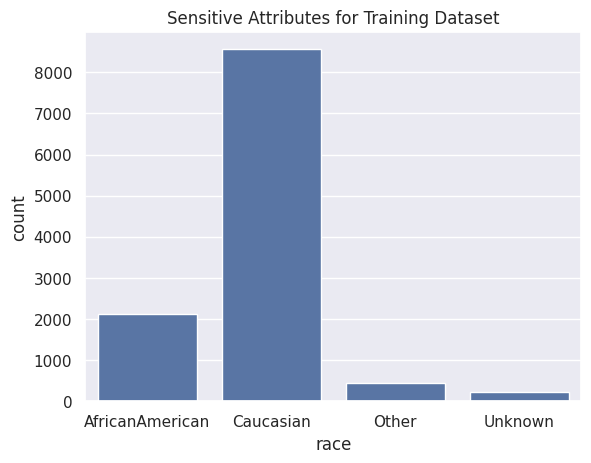

In [ ]:
sns.countplot(x="race", data=A_train_bal)
plt.title("Sensitive Attributes for Training Dataset")
sensitive_train = plt

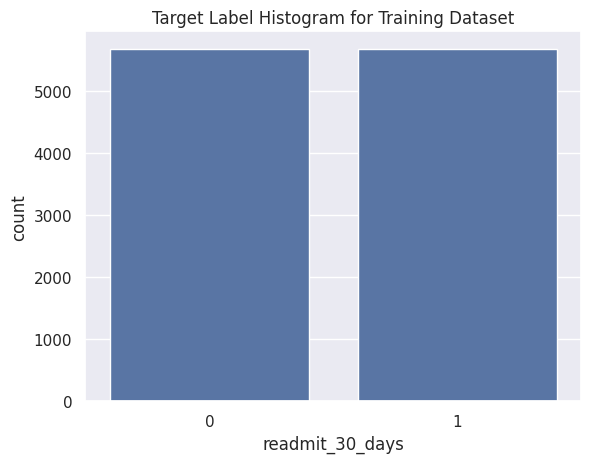

In [ ]:
sns.countplot(x=Y_train_bal)
plt.title("Target Label Histogram for Training Dataset")
outcome_train = plt

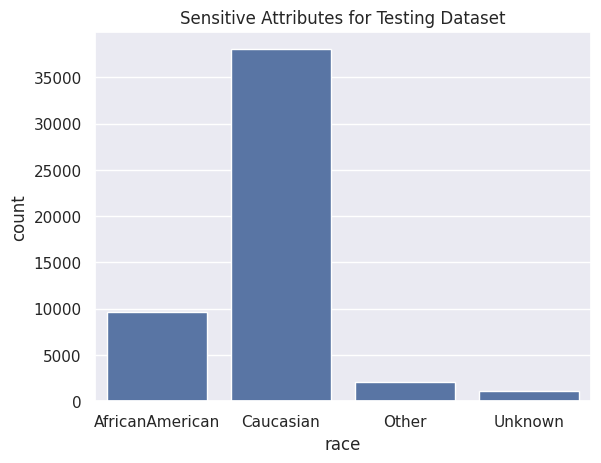

In [ ]:
sns.countplot(x="race", data=A_test)
plt.title("Sensitive Attributes for Testing Dataset")
sensitive_test = plt

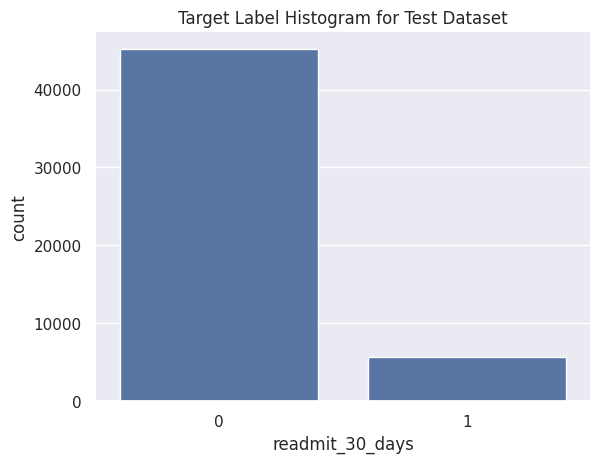

In [ ]:
sns.countplot(x=Y_test)
plt.title("Target Label Histogram for Test Dataset")
outcome_test = plt

## Entrenamiento del modelo

In [ ]:
unmitigated_pipeline = Pipeline(steps=[
    ("preprocessing", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=1000))
])

In [ ]:
unmitigated_pipeline.fit(X_train_bal, Y_train_bal)

Pipeline(steps=[('preprocessing', StandardScaler()),
                ('logistic_regression', LogisticRegression(max_iter=1000))])

In [ ]:
Y_pred_proba = unmitigated_pipeline.predict_proba(X_test)[:,1]
Y_pred = unmitigated_pipeline.predict(X_test)

### Evaluamos la performance en el conjunto test

In [ ]:
from sklearn.metrics import classification_report, balanced_accuracy_score, accuracy_score

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.92      0.63      0.75     45203
           1       0.16      0.55      0.25      5679

    accuracy                           0.62     50882
   macro avg       0.54      0.59      0.50     50882
weighted avg       0.83      0.62      0.69     50882



In [ ]:
# Show balanced accuracy rate of the 0/1 predictions
balanced_accuracy_score(Y_test, Y_pred), accuracy_score(Y_test, Y_pred)


(np.float64(0.5939333749284794), 0.6249754333556071)

## Evaluación de _fairness_
### Mediciones de los daños relacionados con _fairness_
El objetivo de la evaluación de _fairness_ es responder a la pregunta: ¿Qué grupos de personas pueden verse afectados de manera desproporcionadamente negativa por un sistema de IA y de qué manera?

Los pasos de la evaluación son los siguientes:

1. Identificar daños
2. Identificar los grupos que podrían verse perjudicados.
3. Cuantificar los daños
4. Comparar los daños cuantificados entre los grupos

Examinemos cada uno de estos puntos:

### 1. Identificar los daños

¿Que tipo de daño se puede generar cuando el sistema comete un error? ¿Hay alguno de los errores que sea peor en este caso?

Por ejemplo, en un sistema de selección de solicitudes de empleo, los candidatos calificados que son rechazados automáticamente experimentan un daño en la asignación. En un sistema de transcripción de voz a texto, las altas tasas de error constituyen un daño a la calidad del servicio.

Pensemos en este caso, sabemos que si la persona tiene readmit_30_days es probable que se le asigne un programa de salud.

Positivo: persona volvera al hospital en menos de 30 días. Será admitida en el programa especial.

Falso positivo: la persona ingresa a un programa especial pero en realidad no iba a ser readmitida en el hospital. Consecuencia: desperdicia dinero y oportunidades a otras personas

False Negative: la persona iba a ser readmitida pero el modelo predice que no, se pierde del pograma de ayuda.


### 2. Identificar los grupos que podrían verse perjudicados
En la mayoría de las aplicaciones, consideramos grupos demográficos que incluyen grupos históricamente marginados (por ejemplo, según el género, la raza o el origen étnico). También debemos considerar grupos que sean relevantes para una aplicación particular. Por ejemplo, para la transcripción de voz a texto, grupos basados en el dialecto regional o en ser hablante nativo o no nativo.

También es importante considerar las intersecciones de grupos, por ejemplo, además de considerar los grupos según el género y los grupos según la raza, también es importante considerar sus intersecciones (por ejemplo, mujeres negras, personas latinas no binarias, etc.).

En el escenario sanitario, basándose en el trabajo anterior, nos centramos en grupos definidos por _race_.

### 3. Cuantificar los daños
Definir métricas que cuantifiquen daños o beneficios:

* En el escenario de selección de empleo, necesitamos cuantificar el número de candidatos que están clasificados como "negativos" (no recomendados para el puesto), pero cuya verdadera etiqueta es "positiva" (están calificados). Una posible métrica es la **_false negative rate_**: proporción de candidatos calificados que son descartados.

* En el escenario de conversión de voz a texto, el daño podría medirse mediante la **tasa de error de palabras**, es decir, el número de errores en una transcripción dividido por el número total de palabras.

* En el escenario de la atención sanitaria, podríamos considerar dos métricas para cuantificar daños/beneficios:
    * _false negative rate_: proporción de pacientes que reingresan dentro de los 30 días, pero que no están recomendados para el programa de gestión de la atención; esto cuantifica el daño.


### 4. Comparar los daños cuantificados entre los grupos

El caballo de batalla de la evaluación de _fairness_ son las _métricas desagregadas_, que son **métricas evaluadas en porciones de datos**. Por ejemplo, para medir los daños debidos a errores, comenzaríamos evaluando los errores en cada segmento de datos que corresponde a un grupo que identificamos en el Paso 2. Si algunos de los grupos ven errores mucho mayores que otros grupos, lo señalaríamos como un daño de _fairness_.

Para resumir las disparidades en los errores (u otras métricas), es posible que deseemos informar cantidades como la **diferencia** o la **relación** de los valores de las métricas entre el mejor y el peor segmento. En entornos donde el objetivo es garantizar cierta calidad mínima de servicio (como el reconocimiento de voz), también es significativo informar el **peor desempeño** en todos los grupos considerados.

Por ejemplo, al comparar la tasa de falsos negativos entre grupos definidos por _race_, podemos resumir nuestros hallazgos con una tabla como la siguiente:

| | false negative rate<br>(FNR) |
|---|---|
| AfricanAmerican | 0.43 |
| Caucasian | 0.44 |
| Other | 0.52 |
| Unknown | 0.67 |
| | |
|_largest difference_| 0.24 &nbsp;&nbsp;(best is 0.0)|
|_smallest ratio_| 0.64 &nbsp;&nbsp;(best is 1.0)|
|_maximum_<br>_(worst-case) FNR_|0.67|


#### Evaluación de equidad con MetricFrame
Fairlearn proporciona la estructura de datos llamada MetricFrame para permitir la evaluación de métricas desagregadas. Mostraremos cómo utilizar un objeto MetricFrame para evaluar el clasificador LogisticRegression entrenado en busca de posibles daños relacionados con la equidad.

In [ ]:
!pip install fairlearn

In [ ]:
import fairlearn
fairlearn.__version__

'0.13.0'

In [ ]:
from fairlearn.metrics import (
    MetricFrame,
    true_positive_rate,
    false_positive_rate,
    false_negative_rate,
    selection_rate,
    count,
    false_negative_rate_difference,
    equalized_odds_difference,
    demographic_parity_difference,
    true_negative_rate,
)

# In its simplest form MetricFrame takes four arguments:
#    metric_function with signature metric_function(y_true, y_pred)
#    y_true: array of labels
#    y_pred: array of predictions
#    sensitive_features: array of sensitive feature values

mf1 = MetricFrame(metrics=false_negative_rate,
                  y_true=Y_test,
                  y_pred=Y_pred,
                  sensitive_features=df_test['race'])

# The disaggregated metrics are stored in a pandas Series mf1.by_group:

mf1.by_group

,false_negative_rate
race,
AfricanAmerican,0.428
Caucasian,0.442
Other,0.523
Unknown,0.670


In [ ]:
# The largest difference, smallest ratio and worst-case performance are accessed as
#   mf1.difference(), mf1.ratio(), mf1.group_max()

print(f"difference: {mf1.difference():.3}\n"
      f"ratio: {mf1.ratio():.3}\n"
      f"max across groups: {mf1.group_max():.3}")

difference: 0.242
ratio: 0.639
max across groups: 0.67


In [ ]:
# You can also evaluate multiple metrics by providing a dictionary

metrics_dict = {
    "selection_rate": selection_rate,
    "false_negative_rate": false_negative_rate,
    "balanced_accuracy": balanced_accuracy_score,
    "true_negative_rate": true_negative_rate,
    "true_positive_rate": true_positive_rate,
    "false_positive_rate": false_positive_rate,
}

metricframe_unmitigated = MetricFrame(metrics=metrics_dict,
                  y_true=Y_test,
                  y_pred=Y_pred,
                  sensitive_features=df_test['race'])

# The disaggregated metrics are then stored in a pandas DataFrame:

metricframe_unmitigated.by_group

,selection_rate,false_negative_rate,balanced_accuracy,true_negative_rate,true_positive_rate,false_positive_rate
race,,,,,,
AfricanAmerican,0.400,0.428,0.598,0.623,0.572,0.377
Caucasian,0.391,0.442,0.594,0.630,0.558,0.370
Other,0.328,0.523,0.583,0.689,0.477,0.311
Unknown,0.264,0.670,0.536,0.742,0.330,0.258


In [ ]:
# The largest difference, smallest ratio, and the maximum and minimum values
# across the groups are then all pandas Series, for example:

metricframe_unmitigated.difference()

,0
selection_rate,0.136
false_negative_rate,0.242
balanced_accuracy,0.062
true_negative_rate,0.119
true_positive_rate,0.242
false_positive_rate,0.119


In [ ]:
false_negative_rate_difference(Y_test, Y_pred, sensitive_features=df_test['race'])

np.float64(0.24226137706855794)

In [ ]:
equalized_odds_difference(Y_test, Y_pred, sensitive_features=df_test['race'])

0.242261377068558

In [ ]:
demographic_parity_difference(Y_test, Y_pred, sensitive_features=df_test['race'])

np.float64(0.1362525652936309)

In [ ]:
# You'll probably want to view them transposed:

pd.DataFrame({'difference': metricframe_unmitigated.difference(),
              'ratio': metricframe_unmitigated.ratio(),
              'group_min': metricframe_unmitigated.group_min(),
              'group_max': metricframe_unmitigated.group_max()}).T

,selection_rate,false_negative_rate,balanced_accuracy,true_negative_rate,true_positive_rate,false_positive_rate
difference,0.136,0.242,0.062,0.119,0.242,0.119
ratio,0.660,0.639,0.897,0.840,0.577,0.684
group_min,0.264,0.428,0.536,0.623,0.330,0.258
group_max,0.400,0.670,0.598,0.742,0.572,0.377


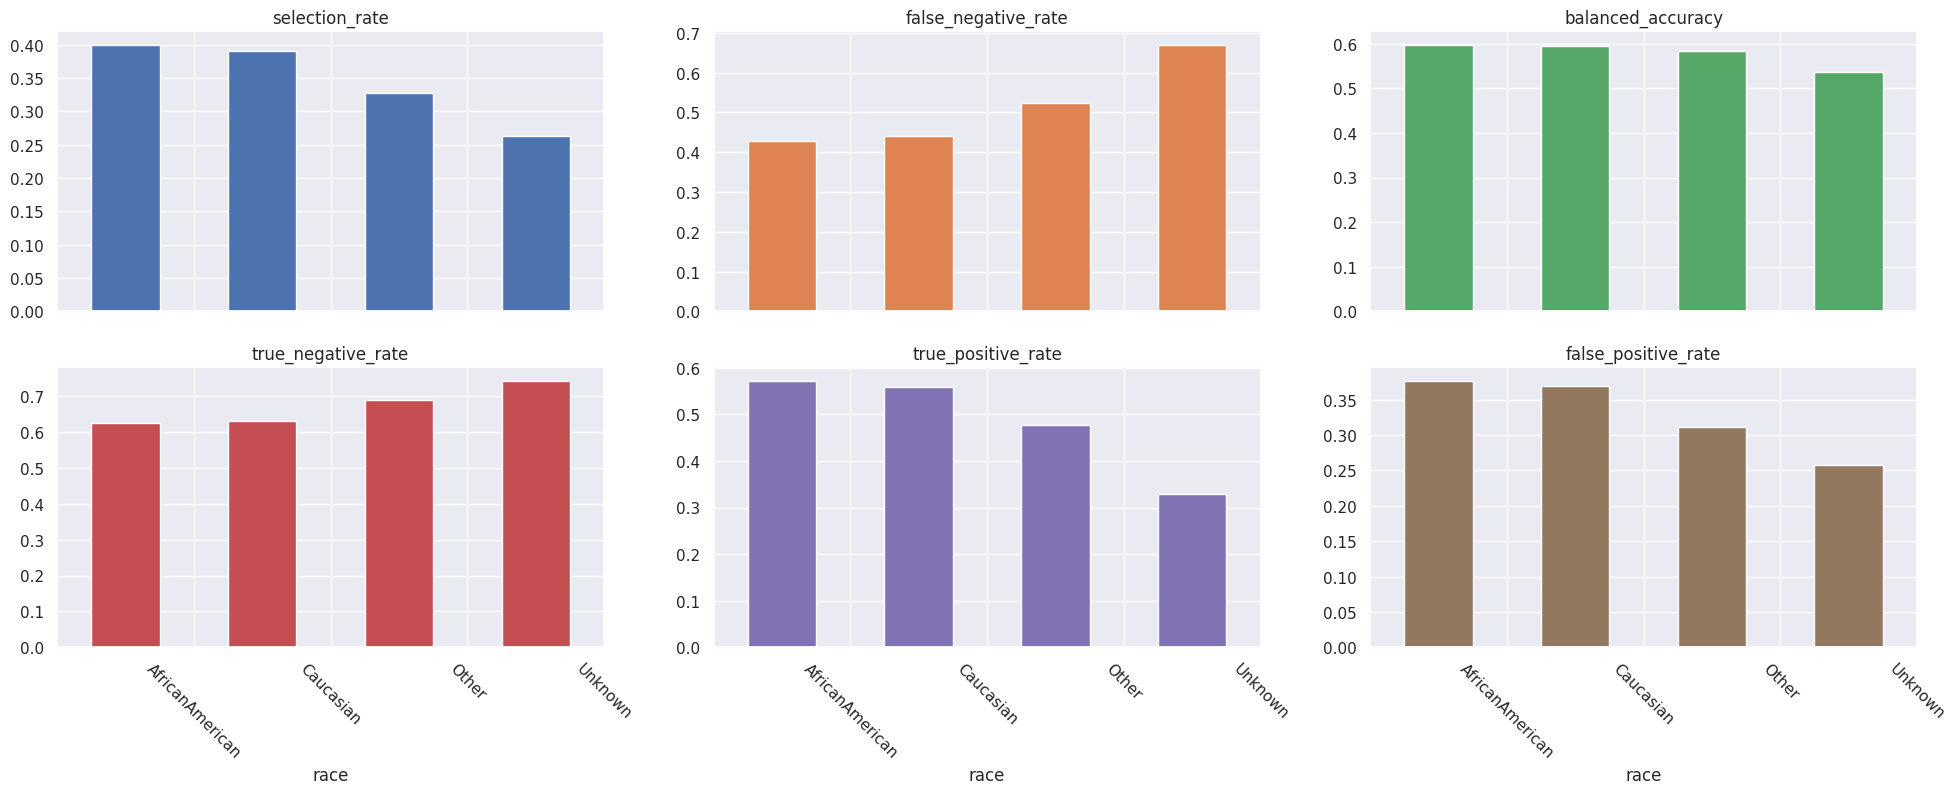

In [ ]:
# You can also easily plot all of the metrics using DataFrame plotting capabilities

metricframe_unmitigated.by_group.plot.bar(subplots=True, layout= [2,3], figsize=(24, 8),
                      legend=False, rot=-45, position=1.5);

Según el gráfico anterior, parece que el grupo _Unknown_ es seleccionado para el programa de gestión de la atención con menos frecuencia que otros grupos, como lo refleja la tasa de selección. Además, este grupo experimenta la mayor _False Negative Rate_, por lo que no se selecciona una fracción mayor de los miembros del grupo que probablemente se beneficiarán del programa de gestión de la atención. Finalmente, _balanced accuracy_ en este grupo también es la más baja.

Observamos disparidad, aunque no incluimos la columna _race_ en nuestro modelo. Hay una variedad de razones por las que pueden ocurrir tales disparidades. Podría deberse a problemas de representación (es decir, no hay suficientes instancias por grupo) o porque la distribución de los atributos en sí difiere entre los grupos (es decir, una relación diferente entre los atributos y la variable objetivo; un ejemplo obvio serían las personas con piel más oscura en los sistemas de reconocimiento facial, pero puede ser mucho más sutil). Las aplicaciones del mundo real suelen presentar ambos tipos de problemas al mismo tiempo.

In [ ]:
metricframe_unmitigated.difference()>0.1

,0
selection_rate,True
false_negative_rate,True
balanced_accuracy,False
true_negative_rate,True
true_positive_rate,True
false_positive_rate,True


In [ ]:
threshold = 0.1

pd.DataFrame({'difference': metricframe_unmitigated.difference(),
              'less_than_threshold': metricframe_unmitigated.difference()<threshold}).T

,selection_rate,false_negative_rate,balanced_accuracy,true_negative_rate,true_positive_rate,false_positive_rate
difference,0.136,0.242,0.062,0.119,0.242,0.119
less_than_threshold,False,False,True,False,False,False





### Referencias:
SciPy 2021 Tutorial: Fairness in AI systems: From social context to practice using Fairlearn by Manojit Nandi, Miroslav Dudík, Triveni Gandhi, Lisa Ibañez, Adrin Jalali, Michael Madaio, Hanna Wallach, Hilde Weerts is licensed under CC BY 4.0.